#### Task2 Q1: Fixed allocation strategy

Read in of the stock level and the probabilities as calculated in the task before

In [5]:
# Manually defined PDFs
pdf_X = {100:0.30,200:0.10,300:0.30,400:0.20,500:0.10}
pdf_Y = {200:0.20,300:0.30,400:0.30,500:0.10,600:0.10}
pdf_Z = {100:0.20,200:0.40,300:0.20,400:0.20}

The discrete convolution of two sequences $\mathbf{a}$ and $\mathbf{b}$ produces a new sequence $\mathbf{c} = \mathbf{a} * \mathbf{b}$ whose $k$-th element is

$$
c_k \;=\; \sum_{i=0}^{k} a_i\,b_{k - i}
\quad\text{for }k = 0,1,2,\dots
$$

In compact vector notation:

$$
\mathbf{c} = \mathbf{a} * \mathbf{b},
\qquad
c_k = \sum_{i=0}^{k} a_i\,b_{k - i}.
$$



PDF of X+Y:
 Stock   P
  300   0.060
  400   0.110
  500   0.180
  600   0.190
  700   0.210
  800   0.130
  900   0.080
 1000   0.030
 1100   0.010

CDF of X+Y:
 Stock   F
  300   0.060
  400   0.170
  500   0.350
  600   0.540
  700   0.750
  800   0.880
  900   0.960
 1000   0.990
 1100   1.000

PDF of X+Y+Z:
 Stock   P
  400   0.012
  500   0.046
  600   0.092
  700   0.144
  800   0.176
  900   0.184
 1000   0.148
 1100   0.106
 1200   0.056
 1300   0.026
 1400   0.008
 1500   0.002

CDF of X+Y+Z:
 Stock   F
  400   0.012
  500   0.058
  600   0.150
  700   0.294
  800   0.470
  900   0.654
 1000   0.802
 1100   0.908
 1200   0.964
 1300   0.990
 1400   0.998
 1500   1.000


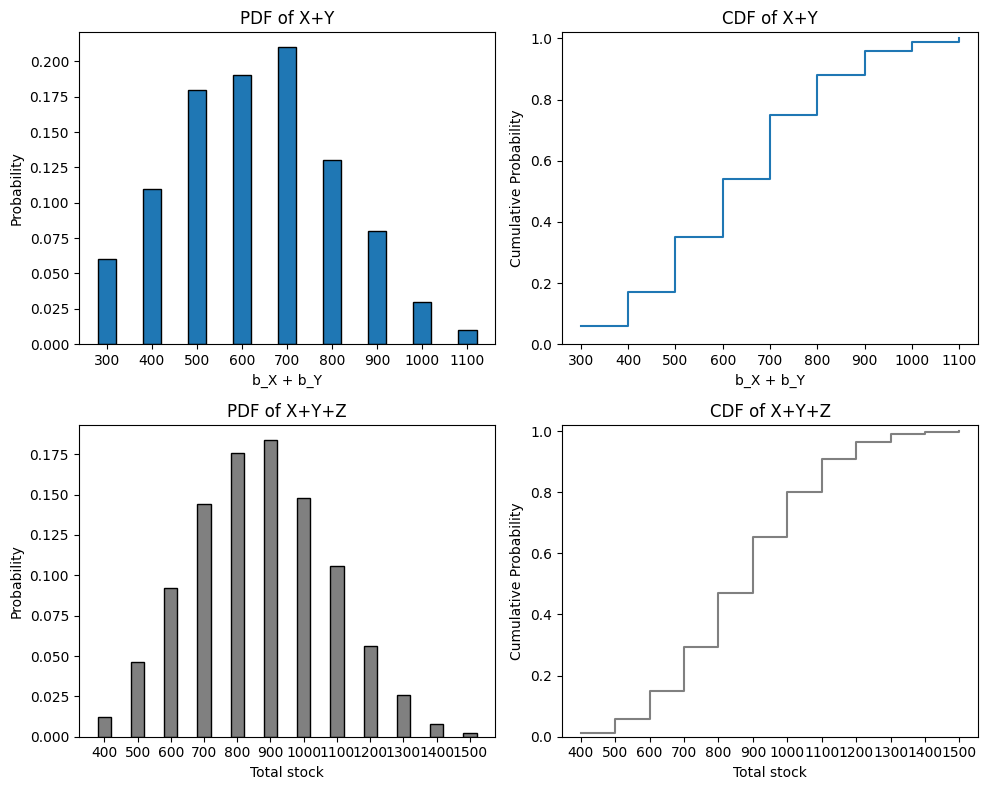

In [13]:
import matplotlib.pyplot as plt

# --- Convolution helper ---
def convolve_pdfs(pdf1, pdf2):
    """
    Discrete convolution of two PMFs (value→prob):
    result[s] = sum_{v1+v2=s} pdf1[v1]*pdf2[v2]
    """
    result = {}
    for v1, p1 in pdf1.items():
        for v2, p2 in pdf2.items():
            s = #---fill
            result[s] = result.get(s, 0) + p1 * p2
    return result

# --- Compute X+Y and X+Y+Z distributions ---
pdf_XY    = convolve_pdfs(pdf_X, pdf_Y)
pdf_total = convolve_pdfs(pdf_XY, pdf_Z)

# --- 1) Print PDF and CDF for X+Y ---
print("PDF of X+Y:")
print(" Stock   P")
for stock in sorted(pdf_XY):
    print(f"{stock:>5}   {pdf_XY[stock]:.3f}")

print("\nCDF of X+Y:")
print(" Stock   F")
cum = 0.0
for stock in sorted(pdf_XY):
    cum += pdf_XY[stock]
    print(f"{stock:>5}   {cum:.3f}")

# --- 2) Print PDF and CDF for X+Y+Z ---
print("\nPDF of X+Y+Z:")
print(" Stock   P")
for stock in sorted(pdf_total):
    print(f"{stock:>5}   {pdf_total[stock]:.3f}")

print("\nCDF of X+Y+Z:")
print(" Stock   F")
cum = 0.0
for stock in sorted(pdf_total):
    cum += pdf_total[stock]
    print(f"{stock:>5}   {cum:.3f}")

# --- 3) Plot the results ---

# Prepare data
levels_XY    = sorted(pdf_XY)
pdf_vals_XY  = [pdf_XY[l] for l in levels_XY]
cdf_vals_XY  = []
cum = 0
for p in pdf_vals_XY:
    cum += p
    cdf_vals_XY.append(cum)

levels_tot   = sorted(pdf_total)
pdf_vals_tot = [pdf_total[l] for l in levels_tot]
cdf_vals_tot = []
cum = 0
for p in pdf_vals_tot:
    cum += p
    cdf_vals_tot.append(cum)

# Create a 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# PDF of X+Y
axes[0,0].bar(levels_XY, pdf_vals_XY, width=40, edgecolor='k')
axes[0,0].set_title('PDF of X+Y')
axes[0,0].set_xlabel('b_X + b_Y')
axes[0,0].set_ylabel('Probability')
axes[0,0].set_xticks(levels_XY)

# CDF of X+Y
axes[0,1].step(levels_XY, cdf_vals_XY, where='post')
axes[0,1].set_title('CDF of X+Y')
axes[0,1].set_xlabel('b_X + b_Y')
axes[0,1].set_ylabel('Cumulative Probability')
axes[0,1].set_ylim(0,1.02)
axes[0,1].set_xticks(levels_XY)

# PDF of X+Y+Z
axes[1,0].bar(levels_tot, pdf_vals_tot, width=40, edgecolor='k', color='gray')
axes[1,0].set_title('PDF of X+Y+Z')
axes[1,0].set_xlabel('Total stock')
axes[1,0].set_ylabel('Probability')
axes[1,0].set_xticks(levels_tot)

# CDF of X+Y+Z
axes[1,1].step(levels_tot, cdf_vals_tot, where='post', color='gray')
axes[1,1].set_title('CDF of X+Y+Z')
axes[1,1].set_xlabel('Total stock')
axes[1,1].set_ylabel('Cumulative Probability')
axes[1,1].set_ylim(0,1.02)
axes[1,1].set_xticks(levels_tot)

plt.tight_layout()
plt.show()

